<a href="https://colab.research.google.com/github/suryansh24-coder/Machine-Learning-Journey/blob/main/Netflix_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [7]:
df = pd.read_csv("Netflix_data.csv")

In [8]:
df.head()

,customer_id,age,subscription_plan,subscription_months,monthly_fee,watch_hours_monthly,movies_watched_monthly,days_since_last_login,devices_used,avg_session_minutes,downloads_monthly,payment_method,payment_failures,customer_complaints,support_tickets,price_increase_exposed,content_satisfaction,recommendation_satisfaction,account_age_months,is_churned
0,NET10000,35,Standard,4,399,15.8,9,4,5,24,3,Wallet,0,0,1,No,5.9,8.0,5,0
1,NET10001,29,Basic,12,249,9.1,5,14,3,26,1,Net Banking,0,1,1,No,6.2,6.2,15,1
2,NET10002,36,Basic,3,199,23.4,15,1,2,33,3,UPI,0,0,0,No,7.7,6.2,7,0
3,NET10003,44,Basic,23,199,30.7,15,1,6,80,3,Wallet,0,2,3,Yes,7.0,6.5,26,0
4,NET10004,28,Standard,10,399,20.0,11,0,2,24,4,UPI,0,0,1,No,8.6,6.2,13,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  10000 non-null  object 
 1   age                          10000 non-null  int64  
 2   subscription_plan            10000 non-null  object 
 3   subscription_months          10000 non-null  int64  
 4   monthly_fee                  10000 non-null  int64  
 5   watch_hours_monthly          10000 non-null  float64
 6   movies_watched_monthly       10000 non-null  int64  
 7   days_since_last_login        10000 non-null  int64  
 8   devices_used                 10000 non-null  int64  
 9   avg_session_minutes          10000 non-null  int64  
 10  downloads_monthly            10000 non-null  int64  
 11  payment_method               10000 non-null  object 
 12  payment_failures             10000 non-null  int64  
 13  customer_complain

In [10]:
df.isnull().sum()

,0
customer_id,0
age,0
subscription_plan,0
subscription_months,0
monthly_fee,0
watch_hours_monthly,0
movies_watched_monthly,0
days_since_last_login,0
devices_used,0
avg_session_minutes,0


In [11]:
df.shape

(10000, 20)

In [12]:
df.head()

,customer_id,age,subscription_plan,subscription_months,monthly_fee,watch_hours_monthly,movies_watched_monthly,days_since_last_login,devices_used,avg_session_minutes,downloads_monthly,payment_method,payment_failures,customer_complaints,support_tickets,price_increase_exposed,content_satisfaction,recommendation_satisfaction,account_age_months,is_churned
0,NET10000,35,Standard,4,399,15.8,9,4,5,24,3,Wallet,0,0,1,No,5.9,8.0,5,0
1,NET10001,29,Basic,12,249,9.1,5,14,3,26,1,Net Banking,0,1,1,No,6.2,6.2,15,1
2,NET10002,36,Basic,3,199,23.4,15,1,2,33,3,UPI,0,0,0,No,7.7,6.2,7,0
3,NET10003,44,Basic,23,199,30.7,15,1,6,80,3,Wallet,0,2,3,Yes,7.0,6.5,26,0
4,NET10004,28,Standard,10,399,20.0,11,0,2,24,4,UPI,0,0,1,No,8.6,6.2,13,0


In [13]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


In [14]:
df.describe()

,age,subscription_months,monthly_fee,watch_hours_monthly,movies_watched_monthly,days_since_last_login,devices_used,avg_session_minutes,downloads_monthly,payment_failures,customer_complaints,support_tickets,content_satisfaction,recommendation_satisfaction,account_age_months,is_churned
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,30.638400,13.522500,489.117000,25.866160,14.629300,5.295300,2.981800,44.480300,4.038800,0.294800,0.409100,0.702000,6.981690,7.139040,16.047200,0.140900
std,8.691479,13.807801,221.790837,16.612576,10.025564,5.919645,1.358916,17.868647,2.018094,0.541223,0.637948,0.828652,1.725641,1.621458,13.925558,0.347936
min,15.000000,1.000000,179.000000,0.500000,0.000000,0.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,24.000000,3.000000,379.000000,13.900000,7.000000,1.000000,2.000000,32.000000,3.000000,0.000000,0.000000,0.000000,5.800000,6.000000,6.000000,0.000000
50%,30.000000,9.000000,419.000000,22.500000,12.000000,3.000000,3.000000,44.000000,4.000000,0.000000,0.000000,1.000000,7.000000,7.200000,12.000000,0.000000
75%,37.000000,19.000000,649.000000,33.600000,19.000000,7.000000,4.000000,57.000000,5.000000,1.000000,1.000000,1.000000,8.200000,8.300000,21.000000,0.000000
max,66.000000,96.000000,949.000000,130.100000,90.000000,48.000000,6.000000,114.000000,13.000000,4.000000,5.000000,5.000000,10.000000,10.000000,99.000000,1.000000


In [15]:
df.value_counts()

,,,,,,,,,,,,,,,,,,,,count
customer_id,age,subscription_plan,subscription_months,monthly_fee,watch_hours_monthly,movies_watched_monthly,days_since_last_login,devices_used,avg_session_minutes,downloads_monthly,payment_method,payment_failures,customer_complaints,support_tickets,price_increase_exposed,content_satisfaction,recommendation_satisfaction,account_age_months,is_churned,
NET19983,33,Standard,10,399,8.5,4,1,5,45,4,Debit Card,1,1,1,Yes,10.0,5.8,13,0,1
NET19982,35,Basic,1,199,8.0,6,4,3,50,4,Wallet,0,0,1,No,7.1,6.1,1,0,1
NET19981,26,Standard,6,419,9.5,5,1,3,49,3,UPI,0,0,0,Yes,7.9,5.9,7,0,1
NET19980,26,Premium,9,669,31.3,22,1,3,38,6,UPI,0,0,1,No,10.0,8.3,13,0,1
NET19979,15,Basic,4,219,19.4,10,2,4,51,6,Credit Card,0,0,1,Yes,5.0,9.2,4,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NET10004,28,Standard,10,399,20.0,11,0,2,24,4,UPI,0,0,1,No,8.6,6.2,13,0,1
NET10003,44,Basic,23,199,30.7,15,1,6,80,3,Wallet,0,2,3,Yes,7.0,6.5,26,0,1
NET10002,36,Basic,3,199,23.4,15,1,2,33,3,UPI,0,0,0,No,7.7,6.2,7,0,1


In [16]:
df.nunique()

,0
customer_id,10000
age,50
subscription_plan,4
subscription_months,92
monthly_fee,16
watch_hours_monthly,837
movies_watched_monthly,78
days_since_last_login,47
devices_used,6
avg_session_minutes,102


In [17]:
df.head()

,customer_id,age,subscription_plan,subscription_months,monthly_fee,watch_hours_monthly,movies_watched_monthly,days_since_last_login,devices_used,avg_session_minutes,downloads_monthly,payment_method,payment_failures,customer_complaints,support_tickets,price_increase_exposed,content_satisfaction,recommendation_satisfaction,account_age_months,is_churned
0,NET10000,35,Standard,4,399,15.8,9,4,5,24,3,Wallet,0,0,1,No,5.9,8.0,5,0
1,NET10001,29,Basic,12,249,9.1,5,14,3,26,1,Net Banking,0,1,1,No,6.2,6.2,15,1
2,NET10002,36,Basic,3,199,23.4,15,1,2,33,3,UPI,0,0,0,No,7.7,6.2,7,0
3,NET10003,44,Basic,23,199,30.7,15,1,6,80,3,Wallet,0,2,3,Yes,7.0,6.5,26,0
4,NET10004,28,Standard,10,399,20.0,11,0,2,24,4,UPI,0,0,1,No,8.6,6.2,13,0


In [18]:
df['is_churned'].value_counts(0)

,count
is_churned,
0,8591
1,1409


<Axes: xlabel='is_churned', ylabel='watch_hours_monthly'>

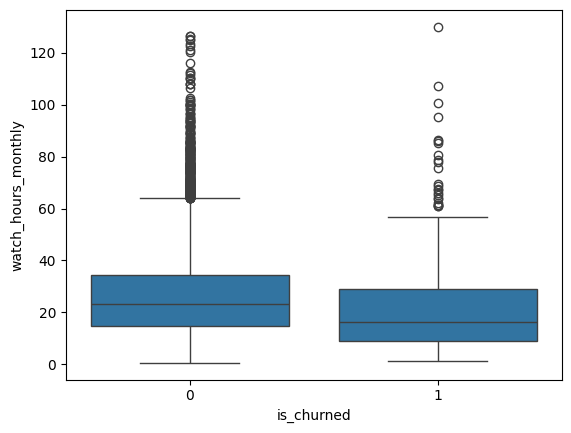

In [19]:
X = df['watch_hours_monthly']
y = df['is_churned']

sns.boxplot(x=y, y=X)

<Axes: xlabel='is_churned', ylabel='watch_hours_monthly'>

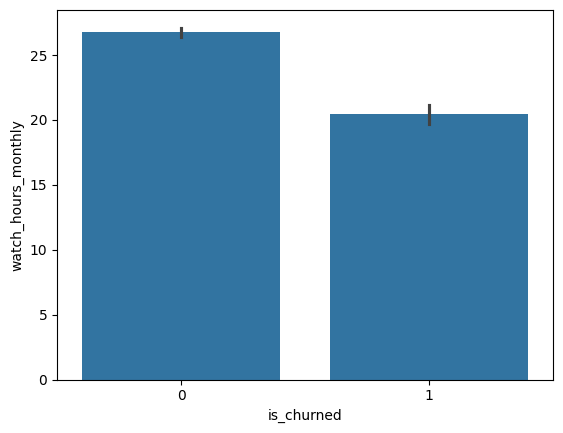

In [20]:
sns.barplot(x=y, y=X)

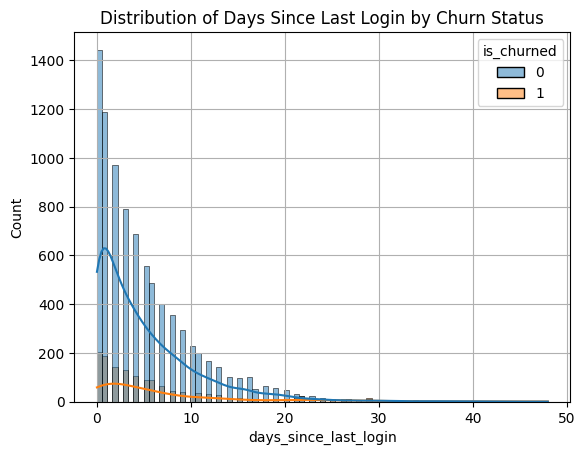

In [21]:
sns.histplot(data=df, x='days_since_last_login', hue='is_churned', kde=True)
plt.title('Distribution of Days Since Last Login by Churn Status')
plt.grid(True)
plt.show()

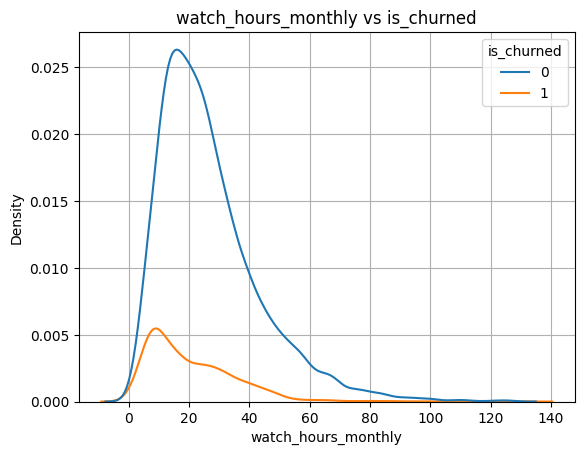

In [22]:
sns.kdeplot(data = df , x=df["watch_hours_monthly"] , hue=df["is_churned"])
plt.title("watch_hours_monthly vs is_churned")
plt.grid(True)
plt.show()

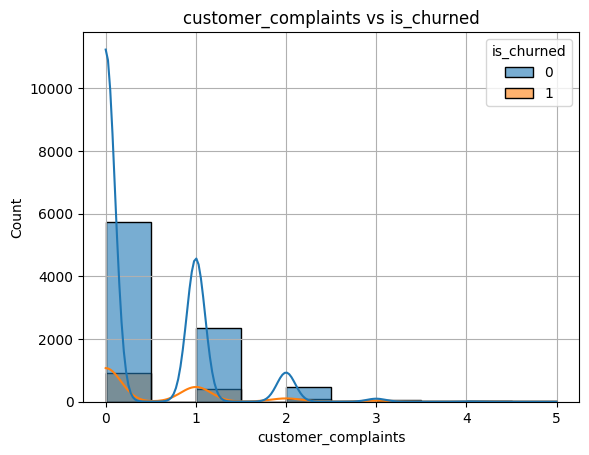

In [23]:
sns.histplot(data=df ,x = df["customer_complaints"] , hue=df["is_churned"],kde=True , alpha=0.6 , bins=10)
plt.title("customer_complaints vs is_churned")
plt.grid(True)
plt.show()

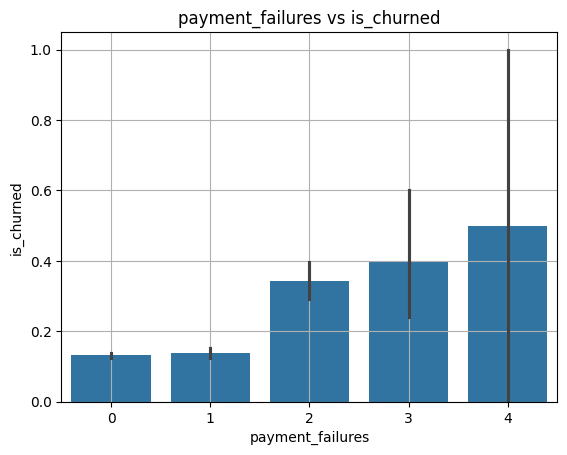

In [24]:
sns.barplot(x=df['payment_failures'], y=df['is_churned'])
plt.title("payment_failures vs is_churned")
plt.grid(True)
plt.show()

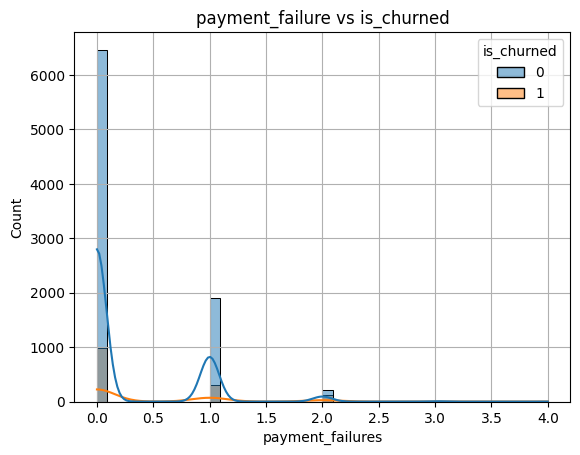

In [25]:
sns.histplot(data=df , x='payment_failures' , hue='is_churned', kde=True)
plt.title("payment_failure vs is_churned")
plt.grid(True)
plt.show()

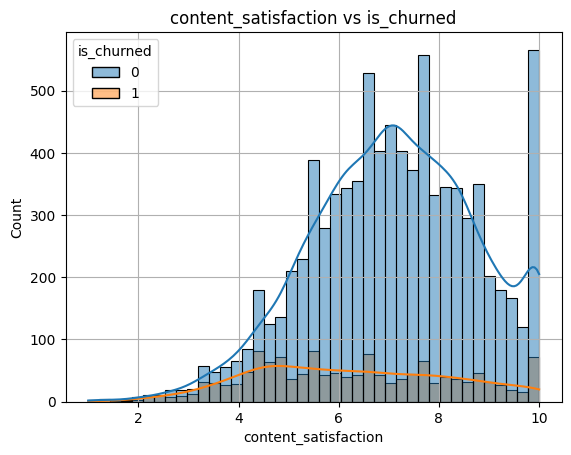

In [26]:
sns.histplot(data=df , x='content_satisfaction' , hue='is_churned', kde=True)
plt.title("content_satisfaction vs is_churned")
plt.grid(True)
plt.show()

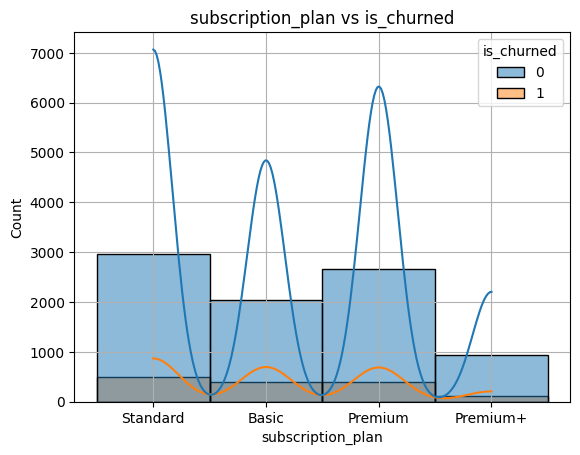

In [27]:
sns.histplot(data=df , x='subscription_plan' , hue='is_churned', kde=True)
plt.title("subscription_plan vs is_churned")
plt.grid(True)
plt.show()

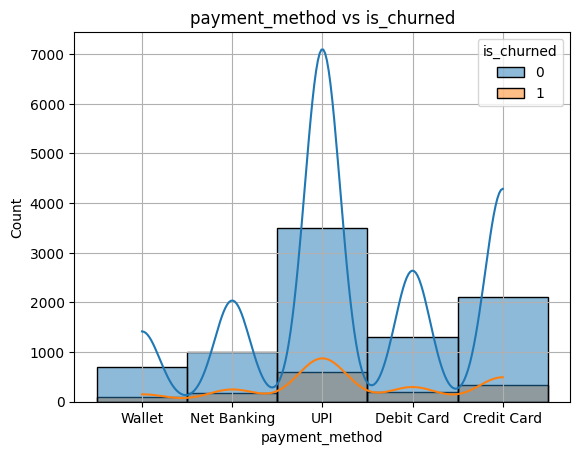

In [28]:
sns.histplot(data=df , x='payment_method' , hue='is_churned', kde=True ,bins=500)
plt.title("payment_method vs is_churned")
plt.grid(True)
plt.show()

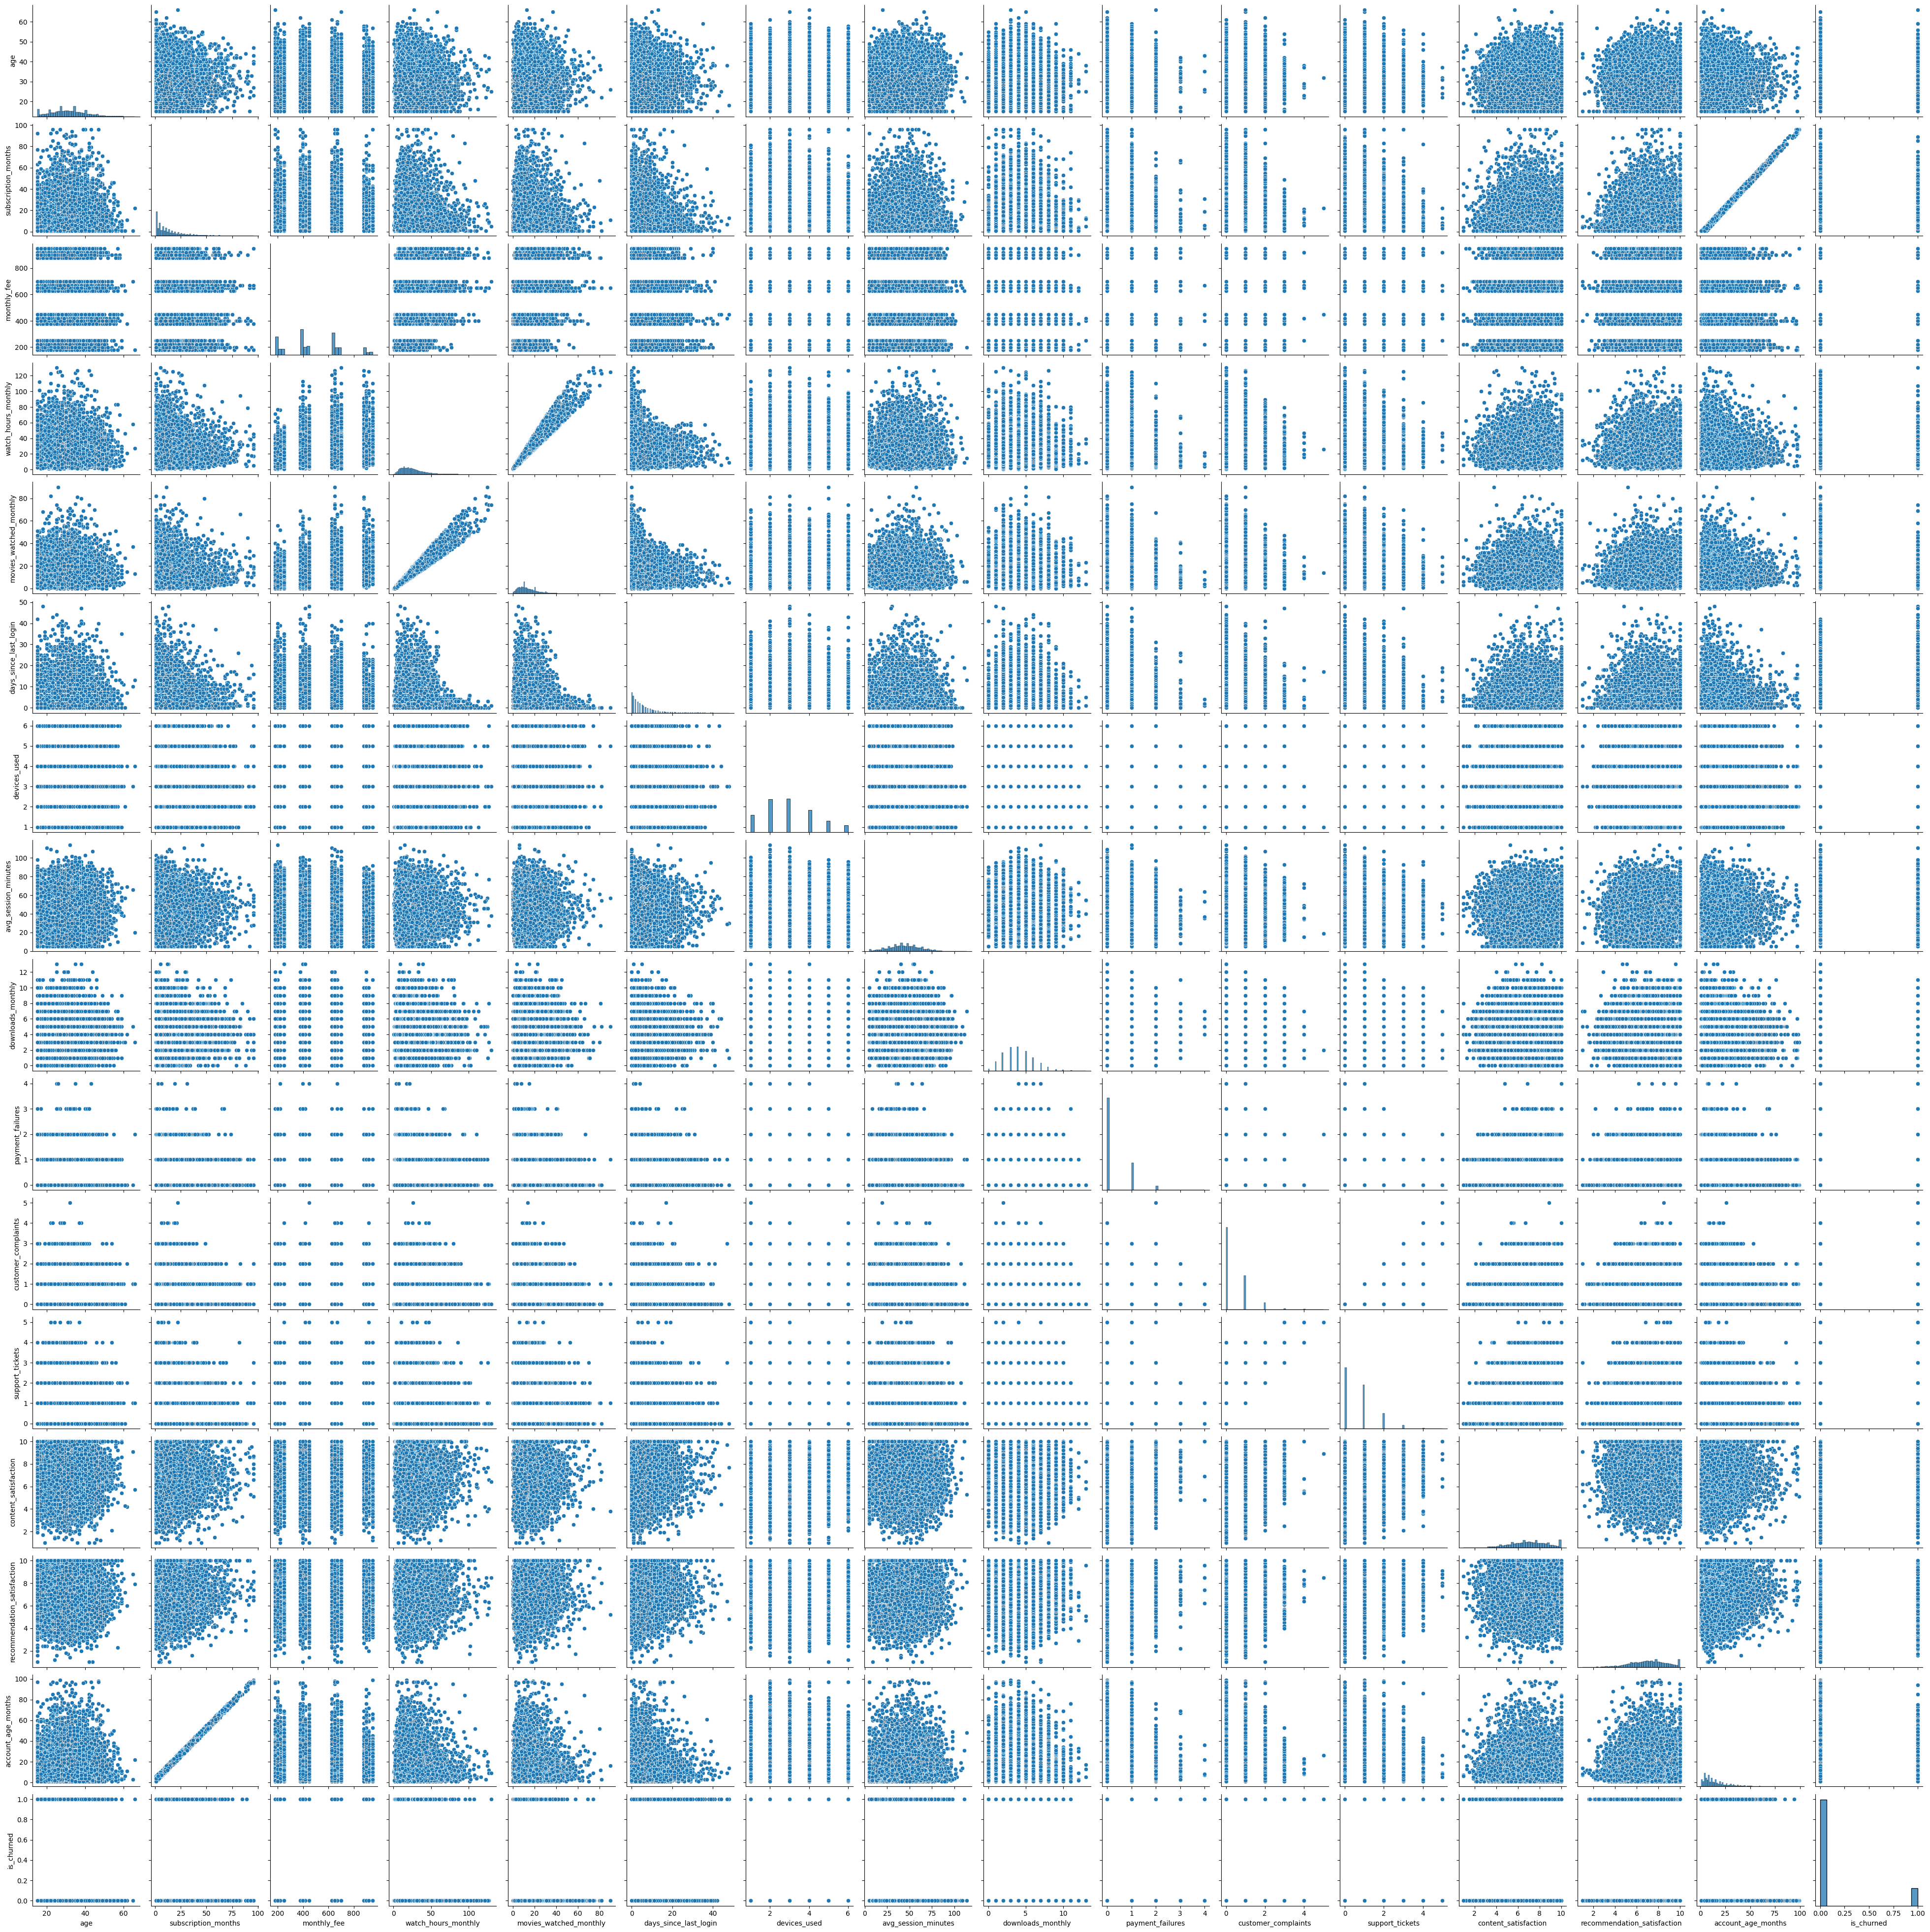

In [29]:
sns.pairplot(df)

<Axes: >

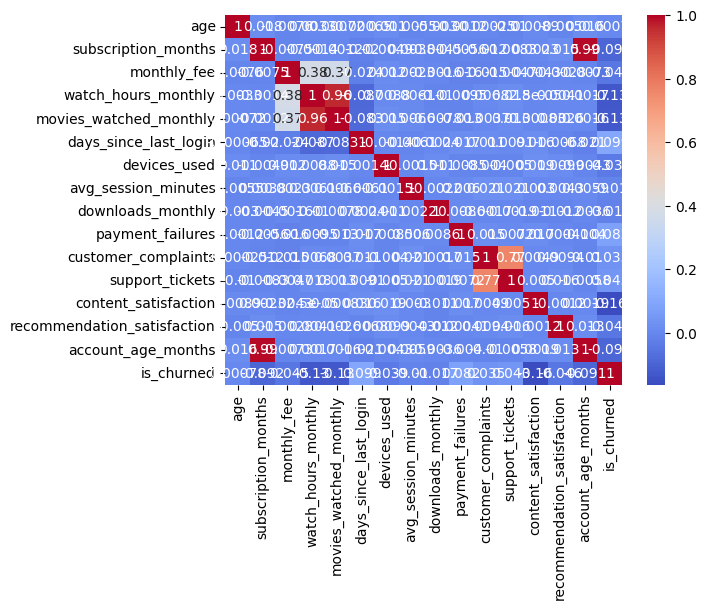

In [30]:
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(),
    annot=True,
    cmap="coolwarm")

In [31]:
df.head()

,customer_id,age,subscription_plan,subscription_months,monthly_fee,watch_hours_monthly,movies_watched_monthly,days_since_last_login,devices_used,avg_session_minutes,downloads_monthly,payment_method,payment_failures,customer_complaints,support_tickets,price_increase_exposed,content_satisfaction,recommendation_satisfaction,account_age_months,is_churned
0,NET10000,35,Standard,4,399,15.8,9,4,5,24,3,Wallet,0,0,1,No,5.9,8.0,5,0
1,NET10001,29,Basic,12,249,9.1,5,14,3,26,1,Net Banking,0,1,1,No,6.2,6.2,15,1
2,NET10002,36,Basic,3,199,23.4,15,1,2,33,3,UPI,0,0,0,No,7.7,6.2,7,0
3,NET10003,44,Basic,23,199,30.7,15,1,6,80,3,Wallet,0,2,3,Yes,7.0,6.5,26,0
4,NET10004,28,Standard,10,399,20.0,11,0,2,24,4,UPI,0,0,1,No,8.6,6.2,13,0


In [32]:
stand = StandardScaler()

In [33]:
X = df.drop(columns=["is_churned", "customer_id"])
y = df["is_churned"]

In [34]:
X_train ,X_test ,y_train ,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [35]:
X_train

,age,subscription_plan,subscription_months,monthly_fee,watch_hours_monthly,movies_watched_monthly,days_since_last_login,devices_used,avg_session_minutes,downloads_monthly,payment_method,payment_failures,customer_complaints,support_tickets,price_increase_exposed,content_satisfaction,recommendation_satisfaction,account_age_months
9254,32,Standard,11,449,36.7,17,5,1,49,6,UPI,0,0,0,No,6.9,7.3,14
1561,24,Basic,3,199,7.5,5,0,3,32,3,Credit Card,0,0,1,Yes,8.3,9.4,8
1670,28,Standard,11,379,10.8,6,0,2,38,3,UPI,0,3,4,No,8.4,7.1,13
6087,17,Basic,15,249,13.6,9,18,3,55,3,Wallet,1,1,2,No,10.0,9.2,18
6669,37,Premium,22,699,16.0,8,13,3,32,4,UPI,0,1,1,No,5.4,8.0,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,25,Premium+,26,899,29.6,19,1,2,61,2,Net Banking,0,0,0,Yes,6.9,8.0,26
5191,30,Standard,5,379,17.2,10,6,3,75,2,Net Banking,0,0,1,Yes,5.9,8.6,8
5390,24,Standard,16,399,10.0,5,7,2,68,4,Debit Card,0,2,2,No,7.7,8.0,21
860,32,Standard,11,449,23.0,12,6,4,51,4,UPI,0,0,0,No,7.7,7.4,15


In [36]:
y_test

,is_churned
6252,0
4684,0
1731,1
4742,0
4521,0
...,...
6412,1
8285,0
7853,0
1095,0


In [39]:
X_train.select_dtypes(include="object").columns

Index(['subscription_plan', 'payment_method', 'price_increase_exposed'], dtype='object')

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler , OneHotEncoder

In [45]:
categorical_cols=[
    'subscription_plan',
    'payment_method' ,
    'price_increase_exposed'
]

In [46]:
numerical_col = X_train.select_dtypes(include=['int64', 'float64']).columns

In [47]:
print(numerical_col)

Index(['age', 'subscription_months', 'monthly_fee', 'watch_hours_monthly',
       'movies_watched_monthly', 'days_since_last_login', 'devices_used',
       'avg_session_minutes', 'downloads_monthly', 'payment_failures',
       'customer_complaints', 'support_tickets', 'content_satisfaction',
       'recommendation_satisfaction', 'account_age_months'],
      dtype='object')


In [48]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_col),
        ('cat', OneHotEncoder(), categorical_cols)
    ])

In [49]:
X_train_preprocessor = preprocessor.fit_transform(X_train)

In [58]:
X_test_preprocessor = preprocessor.transform(X_test)

In [56]:
X_train_preprocessor.shape

(8000, 26)

In [60]:
X_test_preprocessor.shape

(2000, 26)

In [62]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=42 , max_iter=1000)
model.fit(X_train_preprocessor , y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [63]:
y_pred = model.predict(X_test_preprocessor)

In [64]:
print("Accuracy : " , accuracy_score(y_test , y_pred))
print("\nClassification Report: \n" , classification_report(y_test , y_pred))

Accuracy :  0.8645

Classification Report: 
               precision    recall  f1-score   support

           0       0.87      1.00      0.93      1721
           1       0.79      0.04      0.08       279

    accuracy                           0.86      2000
   macro avg       0.83      0.52      0.50      2000
weighted avg       0.85      0.86      0.81      2000



In [65]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1718    3]
 [ 268   11]]


In [66]:
X_train_preprocessor

array([[ 0.15167496, -0.1852027 , -0.17867985, ...,  0.        ,
         1.        ,  0.        ],
       [-0.76861298, -0.76503701, -1.30596198, ...,  0.        ,
         0.        ,  1.        ],
       [-0.30846901, -0.1852027 , -0.49431885, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.76861298,  0.17719374, -0.40413628, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.15167496, -0.1852027 , -0.17867985, ...,  0.        ,
         1.        ,  0.        ],
       [-1.80393692,  0.75702805, -0.49431885, ...,  0.        ,
         1.        ,  0.        ]])

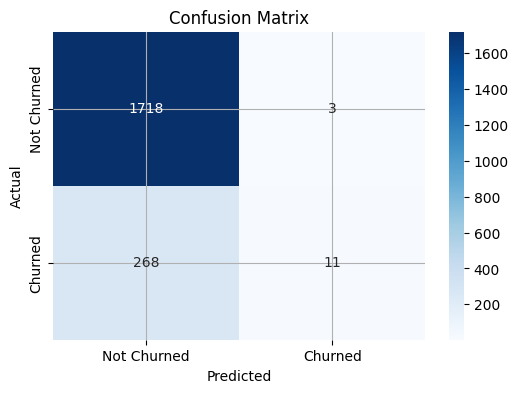

In [69]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True , fmt='d' , cmap='Blues' ,  xticklabels=['Not Churned', 'Churned'],
    yticklabels=['Not Churned', 'Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.grid(True)
plt.show()

In [71]:
from sklearn.linear_model import LogisticRegression

balanced_model = LogisticRegression(class_weight='balanced', random_state=42)
balanced_model.fit(X_train_preprocessor, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [72]:
balanced_model.fit(X_train_preprocessor , y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [73]:
y_pred_balanced = balanced_model.predict(X_test_preprocessor)

In [74]:
print("Accuracy : " , accuracy_score(y_test , y_pred_balanced))
print("\nClassification Report: \n" , classification_report(y_test , y_pred_balanced))

Accuracy :  0.6545

Classification Report: 
               precision    recall  f1-score   support

           0       0.92      0.65      0.76      1721
           1       0.24      0.66      0.35       279

    accuracy                           0.65      2000
   macro avg       0.58      0.66      0.56      2000
weighted avg       0.83      0.65      0.71      2000



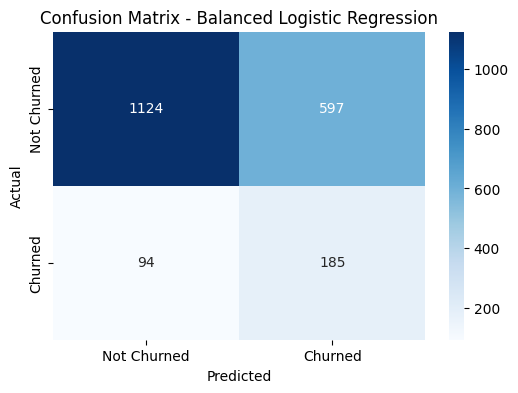

In [75]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_balanced = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_balanced,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Churned', 'Churned'],
    yticklabels=['Not Churned', 'Churned']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Balanced Logistic Regression')
plt.show()

In [76]:
comparison = {
    "Model": ["Original Logistic Regression", "Balanced Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_balanced)
    ],
    "Churn Recall": [
        classification_report(y_test, y_pred, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_balanced, output_dict=True)["1"]["recall"]
    ],
    "Churn F1": [
        classification_report(y_test, y_pred, output_dict=True)["1"]["f1-score"],
        classification_report(y_test, y_pred_balanced, output_dict=True)["1"]["f1-score"]
    ]
}

comparison_df = pd.DataFrame(comparison)
comparison_df

,Model,Accuracy,Churn Recall,Churn F1
0,Original Logistic Regression,0.8645,0.039427,0.075085
1,Balanced Logistic Regression,0.6545,0.663082,0.348728


In [78]:
dl = DecisionTreeClassifier(random_state=42 , class_weight='balanced' , max_depth=5)
dl.fit(X_train_preprocessor , y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [81]:
y_pred_dl = dl.predict(X_test_preprocessor)

In [82]:
print("Accuracy : " , accuracy_score(y_test , y_pred_dl))
print("\nClassification Report: \n" , classification_report(y_test , y_pred_dl))

Accuracy :  0.746

Classification Report: 
               precision    recall  f1-score   support

           0       0.92      0.77      0.84      1721
           1       0.29      0.58      0.39       279

    accuracy                           0.75      2000
   macro avg       0.61      0.68      0.61      2000
weighted avg       0.83      0.75      0.78      2000



In [86]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore' , sparse_output=False)

In [87]:
X_cat_encoded = ohe.fit_transform(X_train[categorical_cols])
X_cat_encoded

array([[0., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [91]:
print(X_cat_encoded)

[[0. 0. 0. ... 0. 1. 0.]
 [1. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]]


In [93]:
ohe.get_feature_names_out(categorical_cols)

array(['subscription_plan_Basic', 'subscription_plan_Premium',
       'subscription_plan_Premium+', 'subscription_plan_Standard',
       'payment_method_Credit Card', 'payment_method_Debit Card',
       'payment_method_Net Banking', 'payment_method_UPI',
       'payment_method_Wallet', 'price_increase_exposed_No',
       'price_increase_exposed_Yes'], dtype=object)

In [95]:
rf_model = RandomForestClassifier(random_state=42 , class_weight='balanced' , n_estimators=200 , max_depth=10)
rf_model.fit(X_train_preprocessor , y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [96]:
y_pred_rf = rf_model.predict(X_test_preprocessor)

In [97]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8075

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      1721
           1       0.33      0.38      0.36       279

    accuracy                           0.81      2000
   macro avg       0.62      0.63      0.62      2000
weighted avg       0.82      0.81      0.81      2000



In [98]:
def predict_churn(customer_data):
  customer_processed = preprocessor.transform(customer_data)
  prediction = balanced_model.predict(customer_processed)

  if prediction[0] == 1 :
    return "Customer is likely to churn !"
  else:
    return "Customer is unlikely to churn."

In [99]:
print(X.columns.tolist())

['age', 'subscription_plan', 'subscription_months', 'monthly_fee', 'watch_hours_monthly', 'movies_watched_monthly', 'days_since_last_login', 'devices_used', 'avg_session_minutes', 'downloads_monthly', 'payment_method', 'payment_failures', 'customer_complaints', 'support_tickets', 'price_increase_exposed', 'content_satisfaction', 'recommendation_satisfaction', 'account_age_months']


In [101]:
import pandas as pd

customer = pd.DataFrame([{
    'age': int(input("Enter age: ")),
    'subscription_plan': input("Enter subscription plan (Basic/Standard/Premium): "),
    'subscription_months': int(input("Enter subscription months: ")),
    'monthly_fee': float(input("Enter monthly fee: ")),
    'watch_hours_monthly': float(input("Enter monthly watch hours: ")),
    'movies_watched_monthly': int(input("Enter movies watched monthly: ")),
    'days_since_last_login': int(input("Enter days since last login: ")),
    'devices_used': int(input("Enter number of devices used: ")),
    'avg_session_minutes': float(input("Enter average session minutes: ")),
    'downloads_monthly': int(input("Enter monthly downloads: ")),
    'payment_method': input("Enter payment method: "),
    'payment_failures': int(input("Enter payment failures: ")),
    'customer_complaints': int(input("Enter customer complaints: ")),
    'support_tickets': int(input("Enter support tickets: ")),
    'price_increase_exposed': input("Was customer exposed to price increase? (Yes/No): "),
    'content_satisfaction': int(input("Enter content satisfaction (1-5): ")),
    'recommendation_satisfaction': int(input("Enter recommendation satisfaction (1-5): ")),
    'account_age_months': int(input("Enter account age in months: "))
}])
customer_processed = preprocessor.transform(customer)
prediction = balanced_model.predict(customer_processed)
if prediction[0] == 1:
    print("⚠️ Customer is likely to churn.")
else:
    print("✅ Customer is unlikely to churn.")

Enter age: 18
Enter subscription plan (Basic/Standard/Premium): Basic
Enter subscription months: 5
Enter monthly fee: 1200
Enter monthly watch hours: 5
Enter movies watched monthly: 4
Enter days since last login: 3
Enter number of devices used: 3
Enter average session minutes: 55
Enter monthly downloads: 5
Enter payment method: UPI
Enter payment failures: 4
Enter customer complaints: 5
Enter support tickets: 2
Was customer exposed to price increase? (Yes/No): Yes
Enter content satisfaction (1-5): 3
Enter recommendation satisfaction (1-5): 3
Enter account age in months: 37
